# edit distance dans corss vlaide ciuster

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10620\1957931760.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 99529
Standardisation des données...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10620\1957931760.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision split : 95.00%
Test sur sujet sorti : 2
Précision split : 90.00%
Test sur sujet sorti : 3
Précision split : 98.00%
Test sur sujet sorti : 4
Précision split : 99.00%
Test sur sujet sorti : 5
Précision split : 90.00%
Test sur sujet sorti : 6
Précision split : 80.00%
Test sur sujet sorti : 7
Précision split : 89.00%
Test sur sujet sorti : 8
Précision split : 97.00%
Test sur sujet sorti : 9
Précision split : 96.00%
Test sur sujet sorti : 10
Précision split : 98.00%

=== EXACTITUDE GLOBALE : 93.20% ===


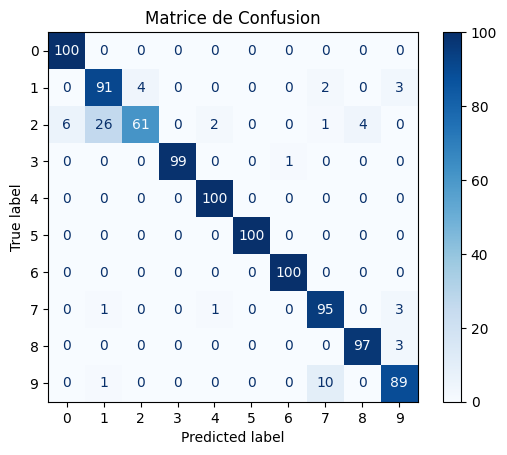

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue

print(f"Nombre total d'observations chargées : {len(df)}")


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation des données...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])

    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len
        }

        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame(res_dict))

    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)



def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df_in, subj_out):
    return df_in[df_in["subject"] != subj_out], df_in[df_in["subject"] == subj_out]

def testmodel(df_target, loop_range=10, k_knn=7, k_clusters=50):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        print(f"Test sur sujet sorti : {i}")
        train_df, test_df = dict_creation_userout(df_target, i)

        if test_df.empty: continue

        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision split : {accuracy_score(y_true, y_pred):.2%}")


    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de Confusion")
    plt.show()

testmodel(df100)

# lcss cluser 20 knn 3 cluseter dedans

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17644\1356518853.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 99529
Standardisation en cours...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17644\1356518853.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

--- TEST SUJET SORTI : 1 ---
Précision sujet 1 : 99.00%

--- TEST SUJET SORTI : 2 ---
Précision sujet 2 : 88.00%

--- TEST SUJET SORTI : 3 ---
Précision sujet 3 : 98.00%

--- TEST SUJET SORTI : 4 ---
Précision sujet 4 : 98.00%

--- TEST SUJET SORTI : 5 ---
Précision sujet 5 : 92.00%

--- TEST SUJET SORTI : 6 ---
Précision sujet 6 : 76.00%

--- TEST SUJET SORTI : 7 ---
Précision sujet 7 : 89.00%

--- TEST SUJET SORTI : 8 ---
Précision sujet 8 : 97.00%

--- TEST SUJET SORTI : 9 ---
Précision sujet 9 : 95.00%

--- TEST SUJET SORTI : 10 ---
Précision sujet 10 : 95.00%

=== EXACTITUDE GLOBALE KNN-LCSS : 92.70% ===


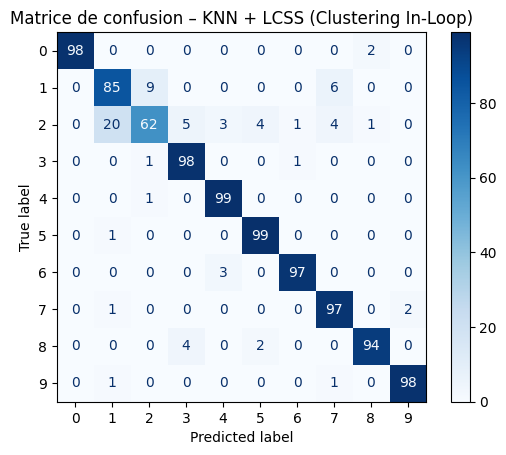

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:

        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)



def cluster_and_symbolize(train_df, test_df, k_clusters=20):

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)

        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)



def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):

    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def testmodel(df_input, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        # Séparation User-Out
        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty:
            continue

        print(f"\n--- TEST SUJET SORTI : {i} ---")


        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE KNN-LCSS : {final_acc:.2%} ===")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – KNN + LCSS (Clustering In-Loop)")
    plt.show()


testmodel(df100)

# transformer

--- 1. Début du Chargement du Domaine 3 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé
Nombre total d'observations chargées : 99529


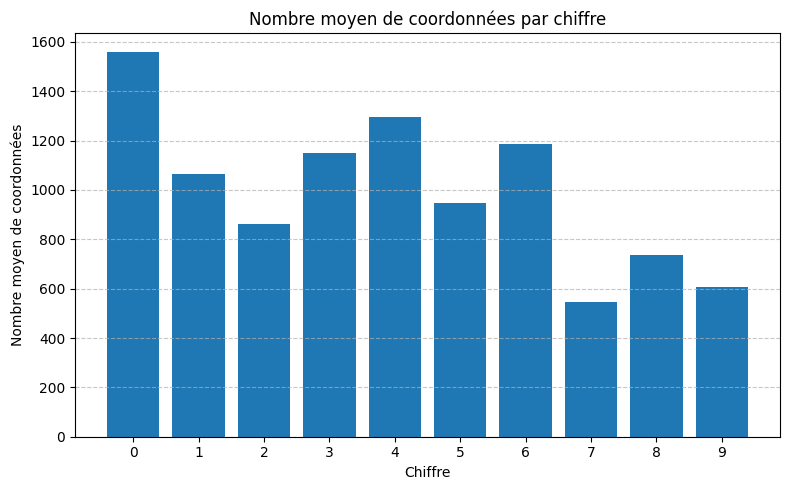

Chiffre 0 : 7534.30 s
Chiffre 1 : 5800.70 s
Chiffre 2 : 4499.00 s
Chiffre 3 : 7059.90 s
Chiffre 4 : 7407.10 s
Chiffre 5 : 4318.60 s
Chiffre 6 : 5602.90 s
Chiffre 7 : 2794.70 s
Chiffre 8 : 4108.20 s
Chiffre 9 : 2912.20 s


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17976\3730711776.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



--- Test subject OUT : 1 ---

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.0989 - loss: 2.4177
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.6056 - loss: 1.1200
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9278 - loss: 0.2293
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - accuracy: 0.9489 - loss: 0.1548
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9400 - loss: 0.2008
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.9789 - loss: 0.0858
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.9800 - loss: 0.0692
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9900 - loss: 0.0365
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9978 - loss: 0.0118
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step - accuracy: 1.0000 - loss: 0.0045
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 12/50
29/29 ━━

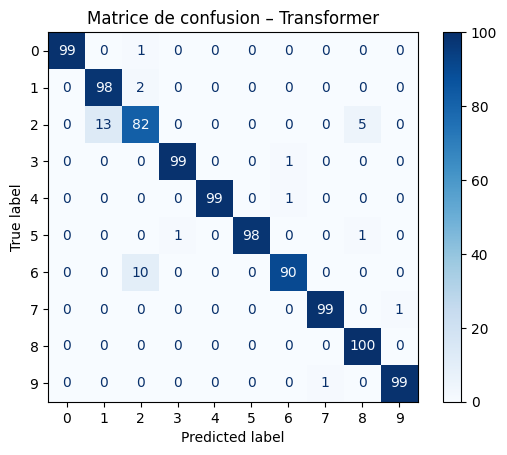

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"
DOMAIN_ID = 3


df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)

                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except FileNotFoundError:
                continue
            except Exception:
                continue


if not df_list:
    raise ValueError("Aucun fichier n'a pu être chargé. Vérifiez le chemin et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")




def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)




def resample_gesture(df_in, target_len=100):
    resampled_data = []

    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))

    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)




def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test




class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]




def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = models.Sequential([
        layers.Dense(dff, activation="relu"),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

def create_transformer_model(input_shape, num_classes, seq_len=100):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model




def test_transformer_user_independent(df_data, loop_range=10, epochs=30, batch_size=32, verbose_fit=1):
    total_true, total_pred = [], []

    for subj_out in range(1, loop_range + 1):
        if df_data[df_data['subject'] == subj_out].empty: continue

        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)

        n_classes = len(np.unique(df_data['gesture']))
        input_shape = (X_train.shape[1], X_train.shape[2])

        model = create_transformer_model(input_shape=input_shape, num_classes=n_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose_fit)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale Transformer : {final_acc:.2%}")

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Transformer")
    plt.show()


test_transformer_user_independent(df100, loop_range=10, epochs=50, batch_size=32, verbose_fit=1)

#lstm

--- 1. Début du Chargement du Domaine 3 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé
✅ Nombre total d'observations chargées : 99529

--- 2. Analyse Exploratoire ---


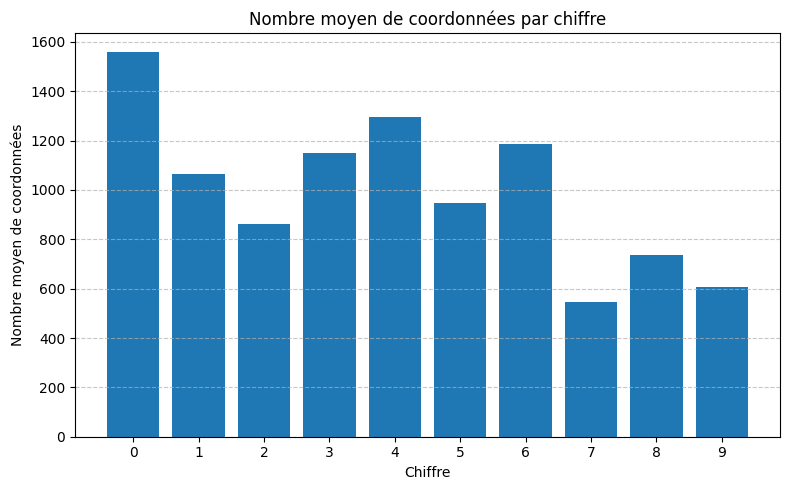

Chiffre 0 : 7534.30 s
Chiffre 1 : 5800.70 s
Chiffre 2 : 4499.00 s
Chiffre 3 : 7059.90 s
Chiffre 4 : 7407.10 s
Chiffre 5 : 4318.60 s
Chiffre 6 : 5602.90 s
Chiffre 7 : 2794.70 s
Chiffre 8 : 4108.20 s
Chiffre 9 : 2912.20 s

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_21324\2725923359.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur 100...

--- Test subject OUT : 1 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 1 : 95.00%

--- Test subject OUT : 2 ---


...

Exactitude subject 8 : 100.00%

--- Test subject OUT : 9 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 9 : 94.00%

--- Test subject OUT : 10 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 10 : 94.00%

Exactitude globale LSTM : 94.00%


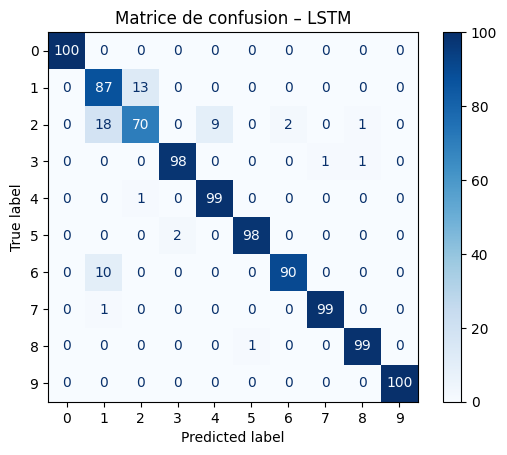

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"
DOMAIN_ID = 3

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except (FileNotFoundError, Exception):
                continue


if not df_list:
    raise ValueError(" Aucun fichier n'a été chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Nombre total d'observations chargées : {len(df)}")



print("\n--- 2. Analyse Exploratoire ---")
grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur 100...")
df100 = resample_gesture(df)



def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test



def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, dropout=0.2, input_shape=input_shape),
        layers.LSTM(256, dropout=0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



def test_lstm_user_independent(df_data, loop_range=10, epochs=50, batch_size=16):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)


        all_labels = np.unique(df_data['gesture'])
        num_classes = int(max(all_labels) + 1)

        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)


        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)


        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale LSTM : {final_acc:.2%}")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – LSTM")
    plt.show()


test_lstm_user_independent(df100)

#dtw

--- Début du Chargement ---
✅ Données chargées : 99529 lignes.


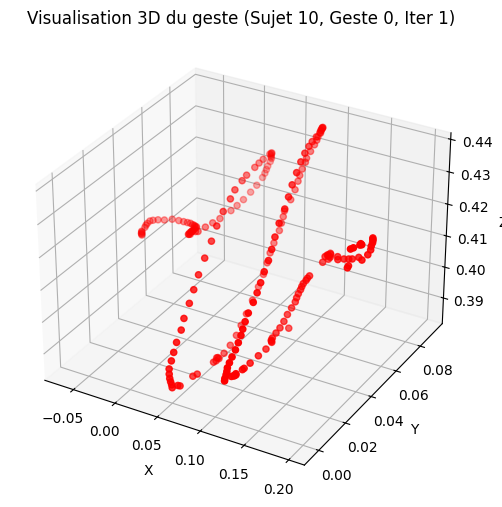


--- Durée moyenne des gestes (s) ---
gesture
0    7534.3
1    5800.7
2    4499.0
3    7059.9
4    7407.1
5    4318.6
6    5602.9
7    2794.7
8    4108.2
9    2912.2
Name: duration, dtype: float64


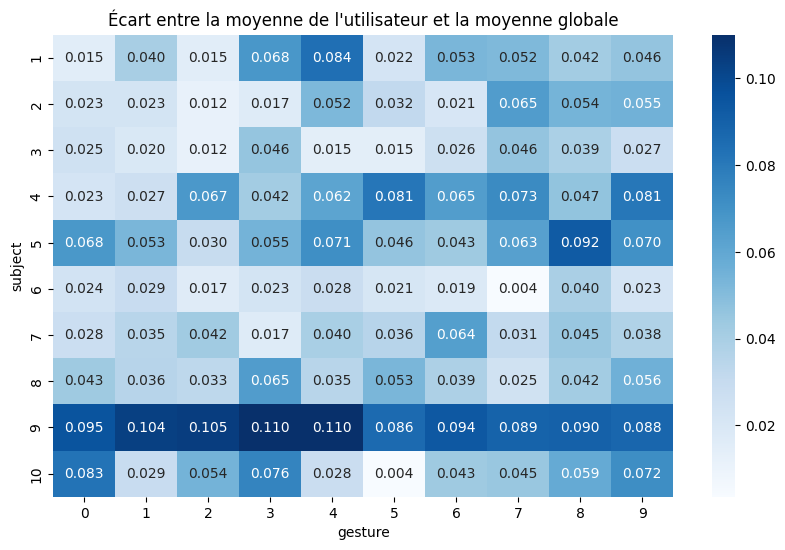

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10748\1713659362.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 98.00%

--- Test Split OUT : 2 ---
Précision split 2 : 94.00%

--- Test Split OUT : 3 ---
Précision split 3 : 100.00%

--- Test Split OUT : 4 ---
Précision split 4 : 100.00%

--- Test Split OUT : 5 ---
Précision split 5 : 96.00%

--- Test Split OUT : 6 ---
Précision split 6 : 86.00%

--- Test Split OUT : 7 ---
Précision split 7 : 95.00%

--- Test Split OUT : 8 ---
Précision split 8 : 98.00%

--- Test Split OUT : 9 ---
Précision split 9 : 100.00%

--- Test Split OUT : 10 ---
Précision split 10 : 99.00%

✅ Précision GLOBALE : 96.60%


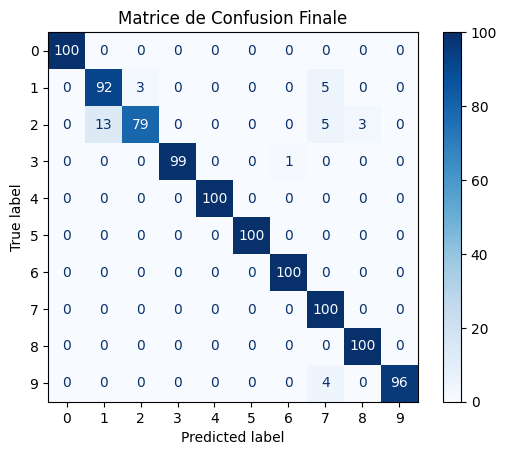

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain3base\DOMAIN3_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("❌ Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Données chargées : {len(df)} lignes.")



subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\n Précision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()


testmodel(dict_creation_userout, df100, loop_range=10, k=3)

## partie 2

## lcss cluster 5 knn 3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=5):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2292860581.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2292860581.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 60.00%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 83.33%
Précision Sujet 9 : 87.78%
Précision Sujet 10 : 86.67%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 81.33% ===


## lcss cluster 5 knn 3 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=5):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3209839499.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3209839499.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 83.33%
Précision Sujet 2 : 75.56%
Précision Sujet 4 : 80.00%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 82.22% ===


## lcss cluster 5 knn 3 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2929626569.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2929626569.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 91.11% ===


## lcs cluster 20 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1999155141.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1999155141.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 64.44%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 93.33%
Précision Sujet 10 : 87.78%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 86.22% ===


## lcss 20 knn 3 test 4 et train 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1057662553.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1057662553.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 97.78%
Précision Sujet 2 : 82.22%
Précision Sujet 4 : 81.11%
Précision Sujet 5 : 95.56%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 89.17% ===


## lcss 20 knnn 3  test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/255378353.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/255378353.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 97.78% ===


## lccs cluster 50 knn3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=50):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3909215852.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3909215852.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 90.00%
Précision Sujet 10 : 90.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 87.33% ===


## lcss 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3865242021.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3865242021.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 92.22%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 77.78%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 85.28% ===


## lcss knn 3 cluster 50 test ur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3770817047.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/3770817047.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 100.00% ===


## lcss cluster 20 knnn 5 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=5, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2084116074.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2084116074.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 67.78%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 91.11%
Précision Sujet 10 : 88.89%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 86.67% ===


## lcss cluster 20 knn 5 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2828270476.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/2828270476.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 96.67%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 80.00%
Précision Sujet 5 : 95.56%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 88.33% ===


# lcss cluseter 20 knn 5 test sujrt 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/909912744.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/909912744.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 98.89% ===


# lcsss cluster 20 knn7 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=7, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN3_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1652316991.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 93457
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1652316991.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 66.67%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 92.22%
Précision Sujet 10 : 87.78%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 86.44% ===


# lcss cluster 20 knn 7 trzine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1510633543.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/1510633543.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 95.56%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 78.89%
Précision Sujet 5 : 94.44%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 87.50% ===


# lcss 20 knn 7 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/716571735.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_13832/716571735.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 98.89% ===


# edity cluster 5 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=5):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3110225731.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3110225731.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 90.00%
Précision Sujet 9 : 96.67%
Précision Sujet 10 : 86.67%

=== EXACTITUDE GLOBALE : 86.44% ===


# edit cluster 5 knn 3 train5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=5):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/1513556795.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/1513556795.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 88.89%
Précision Sujet 2 : 80.00%
Précision Sujet 4 : 83.33%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 85.56% ===


# edit cluset 5 knn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=5):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/678840620.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/678840620.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 97.78% ===


# edit cluster 20 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3412343736.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3412343736.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 81.11%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 98.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 90.00%

=== EXACTITUDE GLOBALE : 90.89% ===


# edit cluster 20 knnn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3839389818.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3839389818.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 97.78%
Précision Sujet 2 : 83.33%
Précision Sujet 4 : 83.33%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 88.61% ===


# eit dist cluser 20 knnn 3 tets sur dujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2033278048.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2033278048.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 98.89% ===


# edit cluster 50 knn 3 test 5 train 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/12151476.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/12151476.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 75.56%
Précision Sujet 7 : 87.78%
Précision Sujet 8 : 97.78%
Précision Sujet 9 : 94.44%
Précision Sujet 10 : 87.78%

=== EXACTITUDE GLOBALE : 88.67% ===


# edit cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3116748457.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/3116748457.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 94.44%
Précision Sujet 2 : 80.00%
Précision Sujet 4 : 80.00%
Précision Sujet 5 : 87.78%

=== EXACTITUDE GLOBALE : 85.56% ===


# edit cluster 50 knn 3 sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2105981361.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_837/2105981361.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 100.00% ===


# edit clusetr 20 knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/3767623598.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/3767623598.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 81.11%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 98.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 88.89%

=== EXACTITUDE GLOBALE : 90.67% ===


# edit clusetr 20 knn 5 train 5 tet 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1530094638.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1530094638.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 96.67%
Précision Sujet 2 : 84.44%
Précision Sujet 4 : 81.11%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 88.06% ===


# edit cluster 20 knn 5 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1735383610.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1735383610.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 98.89% ===


# edit cluster 20 knn 7 train 4 teste 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1453896431.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1453896431.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 80.00%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 98.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 88.89%

=== EXACTITUDE GLOBALE : 90.44% ===


# edit cluster 20 knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/40327524.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/40327524.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 93.33%
Précision Sujet 2 : 84.44%
Précision Sujet 4 : 76.67%
Précision Sujet 5 : 90.00%

=== EXACTITUDE GLOBALE : 86.11% ===


# edit clusterb 20 knn 7 sujet 3 testy

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1777636687.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/1777636687.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 98.89% ===


# test

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/2273333909.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 93457
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1501/2273333909.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 100.00% ===

Affichage du graphique 3D...


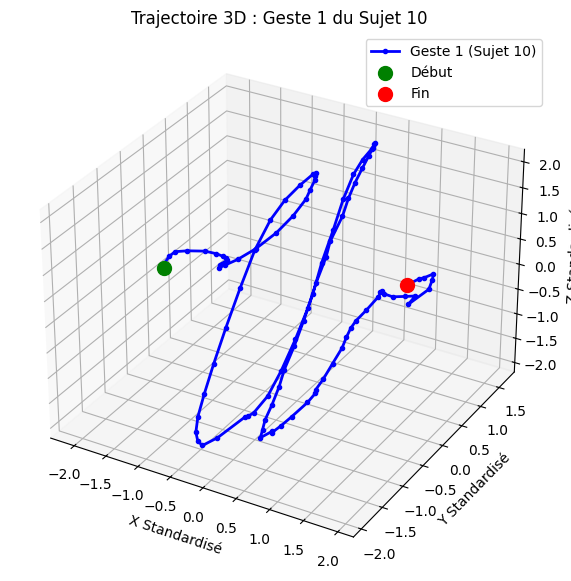

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from mpl_toolkits.mplot3d import Axes3D

# ===========================================================
# 1. CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN4 (adapté à votre structure)
DOMAIN_FOLDER =os.path.expanduser("~/Downloads/DOMAIN3_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes pour ignorer les headers inutiles
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : séparation des colonnes et retrait des guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 2. FONCTIONS DE TRAITEMENT (Symbolisation & Distance)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)
    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 3. TEST FINAL & VISUALISATION 3D
# ===========================================================

def plot_specific_gesture(df_input, subject_id, gesture_id, iter_id=1):
    # Filtrage pour obtenir le geste spécifique
    sample = df_input[(df_input['subject'] == subject_id) &
                      (df_input['gesture'] == gesture_id) &
                      (df_input['iter'] == iter_id)]

    if sample.empty:
        print(f"⚠️ Aucune donnée trouvée pour Sujet {subject_id}, Geste {gesture_id}")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Tracé de la trajectoire
    ax.plot(sample['x_std'], sample['y_std'], sample['z_std'],
            label=f'Geste {gesture_id} (Sujet {subject_id})',
            color='blue', linewidth=2, marker='o', markersize=3)

    # Points Début/Fin
    ax.scatter(sample['x_std'].iloc[0], sample['y_std'].iloc[0], sample['z_std'].iloc[0], color='green', s=100, label='Début')
    ax.scatter(sample['x_std'].iloc[-1], sample['y_std'].iloc[-1], sample['z_std'].iloc[-1], color='red', s=100, label='Fin')

    ax.set_title(f"Trajectoire 3D : Geste {gesture_id} du Sujet {subject_id}")
    ax.set_xlabel('X Standardisé')
    ax.set_ylabel('Y Standardisé')
    ax.set_zlabel('Z Standardisé')
    ax.legend()
    plt.show()

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# --- LANCEMENT ---
if not df100.empty:
    # 1. Analyse statistique
    run_leave_subject_3_out(df100)

    # 2. Visualisation demandée
    print("\nAffichage du graphique 3D...")
    plot_specific_gesture(df100, subject_id=10, gesture_id=1, iter_id=1)

# lstm 64 32 32 tréin 4 test 5

In [2]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/4098386892.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accuracy: 0.3858 - loss: 2.1921 - val_accuracy: 0.0000e+00 - val_loss: 2.1533
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.5648 - loss: 1.7751 - val_accuracy: 0.0000e+00 - val_loss: 2.1547
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.6420 - loss: 1.2698 - val_accuracy: 0.0000e+00 - val_loss: 2.9831
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7006 - loss: 0.9418 - val_accuracy: 0.0000e+00 - val_loss: 3.0815
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.8148 - loss: 0.7175 - val_accuracy: 0.0000e+00 - val_loss: 2.8627
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.8765 - loss: 0.4929 - val_accuracy: 0.0000e+00 - val_loss: 3.2757
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8920 - loss: 0.3557 - val_accuracy: 0.0000e+00 - val_loss: 3.1848
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9074 - loss: 0.3205 - val_

# lstm 64 32 32 train 5 test 4

In [3]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/400826492.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.2765 - loss: 2.1532 - val_accuracy: 0.0000e+00 - val_loss: 1.9133
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.4790 - loss: 1.6450 - val_accuracy: 0.0000e+00 - val_loss: 2.1696
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.7210 - loss: 1.1469 - val_accuracy: 0.0000e+00 - val_loss: 2.8135
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.8370 - loss: 0.7338 - val_accuracy: 0.0000e+00 - val_loss: 3.4794
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8988 - loss: 0.4478 - val_accuracy: 0.0000e+00 - val_loss: 3.8347
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9457 - loss: 0.2674 - val_accuracy: 0.0000e+00 - val_loss: 3.5690
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9506 - loss: 0.1825 - val_accuracy: 0.0000e+00 - val_loss: 3.5434
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.9556 - loss: 0.1468 - va

# lstm 128 32 32 trin 4 test 5

In [4]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/4193118905.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step - accuracy: 0.5031 - loss: 1.9520 - val_accuracy: 0.0000e+00 - val_loss: 3.2313
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.7130 - loss: 1.0996 - val_accuracy: 0.0000e+00 - val_loss: 4.2766
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.8272 - loss: 0.6173 - val_accuracy: 0.0000e+00 - val_loss: 4.2467
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.8889 - loss: 0.4153 - val_accuracy: 0.0000e+00 - val_loss: 3.5136
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.8704 - loss: 0.3556 - val_accuracy: 0.0000e+00 - val_loss: 2.4757
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9043 - loss: 0.2820 - val_accuracy: 0.0000e+00 - val_loss: 2.4916
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.8704 - loss: 0.3130 - val_accuracy: 0.0000e+00 - val_loss: 2.6623
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.8920 - loss: 0.2484 -

# lstm 128 32 32 train 5 test 4

In [5]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/2139677967.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 291ms/step - accuracy: 0.4222 - loss: 1.9588 - val_accuracy: 0.0000e+00 - val_loss: 3.1828
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - accuracy: 0.7160 - loss: 1.0145 - val_accuracy: 0.0000e+00 - val_loss: 4.4898
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.9062 - loss: 0.5138 - val_accuracy: 0.0000e+00 - val_loss: 5.1083
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy: 0.9432 - loss: 0.2576 - val_accuracy: 0.0000e+00 - val_loss: 3.0299
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.9481 - loss: 0.1789 - val_accuracy: 0.0000e+00 - val_loss: 2.6612
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.9481 - loss: 0.1536 - val_accuracy: 0.0000e+00 - val_loss: 1.9595
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.9531 - loss: 0.1360 - val_accuracy: 0.7556 - val_loss: 0.9529
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.9630 - loss: 0.0975 - val

# lstm 256 32 32 tain 4 tets 5

In [6]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/3758589276.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 732ms/step - accuracy: 0.4846 - loss: 1.5626 - val_accuracy: 0.0000e+00 - val_loss: 5.5133
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 654ms/step - accuracy: 0.8241 - loss: 0.6735 - val_accuracy: 0.0000e+00 - val_loss: 3.4465
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 803ms/step - accuracy: 0.8735 - loss: 0.3832 - val_accuracy: 0.0000e+00 - val_loss: 2.5851
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 791ms/step - accuracy: 0.8704 - loss: 0.3671 - val_accuracy: 0.0000e+00 - val_loss: 3.6358
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 649ms/step - accuracy: 0.8673 - loss: 0.3452 - val_accuracy: 0.0000e+00 - val_loss: 1.7876
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 732ms/step - accuracy: 0.9167 - loss: 0.2534 - val_accuracy: 0.5278 - val_loss: 1.0579
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 780ms/step - accuracy: 0.8765 - loss: 0.3163 - val_accuracy: 0.5833 - val_loss: 0.9514
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 644ms/step - accuracy: 0.9198 - loss: 0.2

# lstm 256 32 32 teain 5 test 4

In [7]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/2051629664.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 799ms/step - accuracy: 0.5753 - loss: 1.4358 - val_accuracy: 0.0000e+00 - val_loss: 5.5248
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 672ms/step - accuracy: 0.8247 - loss: 0.5496 - val_accuracy: 0.0000e+00 - val_loss: 3.6751
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 718ms/step - accuracy: 0.9333 - loss: 0.2295 - val_accuracy: 0.0000e+00 - val_loss: 3.0904
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 767ms/step - accuracy: 0.9383 - loss: 0.1774 - val_accuracy: 0.3111 - val_loss: 1.4947
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 763ms/step - accuracy: 0.8716 - loss: 0.4000 - val_accuracy: 0.5778 - val_loss: 0.7790
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 664ms/step - accuracy: 0.8691 - loss: 0.3821 - val_accuracy: 0.0000e+00 - val_loss: 2.8550
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 764ms/step - accuracy: 0.9136 - loss: 0.2726 - val_accuracy: 0.0444 - val_loss: 3.0207
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 766ms/step - accuracy: 0.9531 - loss: 0.1626 - val_

# lstm 128 64 32 train n4 test 5

In [8]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/1298430518.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 499ms/step - accuracy: 0.4969 - loss: 1.9666 - val_accuracy: 0.0000e+00 - val_loss: 2.5630
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 480ms/step - accuracy: 0.7716 - loss: 0.9560 - val_accuracy: 0.0000e+00 - val_loss: 3.6530
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 582ms/step - accuracy: 0.8272 - loss: 0.5353 - val_accuracy: 0.0000e+00 - val_loss: 4.1385
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 503ms/step - accuracy: 0.8457 - loss: 0.4223 - val_accuracy: 0.0000e+00 - val_loss: 2.6978
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 507ms/step - accuracy: 0.8920 - loss: 0.3141 - val_accuracy: 0.0000e+00 - val_loss: 1.5020
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 502ms/step - accuracy: 0.9105 - loss: 0.2253 - val_accuracy: 0.1389 - val_loss: 1.6023
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 421ms/step - accuracy: 0.9198 - loss: 0.2336 - val_accuracy: 0.4444 - val_loss: 1.2305
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 503ms/step - accuracy: 0.8981 - loss: 0.2

# lstm 128 64 32 train 5 test 4

In [9]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/3683935212.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step - accuracy: 0.5457 - loss: 1.8604 - val_accuracy: 0.0000e+00 - val_loss: 4.0437
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step - accuracy: 0.8074 - loss: 0.8259 - val_accuracy: 0.0000e+00 - val_loss: 4.7963
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.8988 - loss: 0.3627 - val_accuracy: 0.0000e+00 - val_loss: 4.6485
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.9358 - loss: 0.2389 - val_accuracy: 0.0000e+00 - val_loss: 1.9588
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 355ms/step - accuracy: 0.9383 - loss: 0.1945 - val_accuracy: 0.5333 - val_loss: 1.2339
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.9531 - loss: 0.1512 - val_accuracy: 0.0889 - val_loss: 2.9845
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.9654 - loss: 0.1281 - val_accuracy: 0.9111 - val_loss: 0.5998
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step - accuracy: 0.9605 - loss: 0.1078 - val_accurac

# lstm 128 16 32 train 4 test 5

In [10]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/275112128.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 329ms/step - accuracy: 0.2438 - loss: 2.1172 - val_accuracy: 0.0000e+00 - val_loss: 3.7352
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.4877 - loss: 1.5948 - val_accuracy: 0.0000e+00 - val_loss: 4.7191
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.7346 - loss: 1.1400 - val_accuracy: 0.0000e+00 - val_loss: 4.1045
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step - accuracy: 0.8426 - loss: 0.7579 - val_accuracy: 0.0000e+00 - val_loss: 3.7920
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.8858 - loss: 0.5109 - val_accuracy: 0.0000e+00 - val_loss: 4.1423
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.8951 - loss: 0.4043 - val_accuracy: 0.0000e+00 - val_loss: 3.6544
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.8889 - loss: 0.3917 - val_accuracy: 0.0000e+00 - val_loss: 3.8056
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step - accuracy: 0.9198 - loss: 0.2673 -

# lstm 128 16 32 treéain 5 test 4

In [11]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/3630324522.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 758ms/step - accuracy: 0.4173 - loss: 1.9111 - val_accuracy: 0.0000e+00 - val_loss: 3.2423
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.6988 - loss: 1.1040 - val_accuracy: 0.0000e+00 - val_loss: 4.8383
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.7605 - loss: 0.7250 - val_accuracy: 0.0000e+00 - val_loss: 3.9332
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.8938 - loss: 0.4913 - val_accuracy: 0.0000e+00 - val_loss: 3.8622
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.9457 - loss: 0.2906 - val_accuracy: 0.0000e+00 - val_loss: 3.4335
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 315ms/step - accuracy: 0.9457 - loss: 0.2040 - val_accuracy: 0.0222 - val_loss: 4.3490
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.9556 - loss: 0.1407 - val_accuracy: 0.6222 - val_loss: 1.5270
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9679 - loss: 0.1278 - val_ac

# lstm 128 32 64 train 4 test 5

In [12]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/1019309842.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 387ms/step - accuracy: 0.2346 - loss: 2.2214 - val_accuracy: 0.0000e+00 - val_loss: 2.5304
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step - accuracy: 0.5772 - loss: 1.8377 - val_accuracy: 0.0000e+00 - val_loss: 2.9264
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 449ms/step - accuracy: 0.6111 - loss: 1.3806 - val_accuracy: 0.0000e+00 - val_loss: 3.4760
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.6420 - loss: 1.0302 - val_accuracy: 0.0000e+00 - val_loss: 4.3110
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 0.8025 - loss: 0.7472 - val_accuracy: 0.0000e+00 - val_loss: 4.2763
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.8642 - loss: 0.5908 - val_accuracy: 0.0000e+00 - val_loss: 4.8285
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.9105 - loss: 0.4493 - val_accuracy: 0.0000e+00 - val_loss: 4.6447
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.9136 - loss: 0.3413 - val_accuracy: 0

# lstm 128 32 64 train 5 test 4

In [13]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/834723502.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step - accuracy: 0.4395 - loss: 2.1146 - val_accuracy: 0.0000e+00 - val_loss: 2.5317
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.5704 - loss: 1.4957 - val_accuracy: 0.0000e+00 - val_loss: 3.1141
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.6815 - loss: 1.0729 - val_accuracy: 0.0000e+00 - val_loss: 3.4966
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - accuracy: 0.7407 - loss: 0.7399 - val_accuracy: 0.0000e+00 - val_loss: 3.9379
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 479ms/step - accuracy: 0.8272 - loss: 0.5261 - val_accuracy: 0.0000e+00 - val_loss: 3.5132
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.9136 - loss: 0.3731 - val_accuracy: 0.0000e+00 - val_loss: 3.1863
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.9259 - loss: 0.2706 - val_accuracy: 0.0000e+00 - val_loss: 3.1827
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - accuracy: 0.9358 - loss: 0.2330 - val_accuracy: 0

# lstm 128 32 16 trai 4 tes 5

In [14]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/1483283721.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.5401 - loss: 1.7247 - val_accuracy: 0.0000e+00 - val_loss: 3.6199
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.7130 - loss: 0.8935 - val_accuracy: 0.0000e+00 - val_loss: 3.4008
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.8642 - loss: 0.4855 - val_accuracy: 0.0000e+00 - val_loss: 3.6634
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.8642 - loss: 0.3521 - val_accuracy: 0.0000e+00 - val_loss: 3.8822
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.8580 - loss: 0.3560 - val_accuracy: 0.0000e+00 - val_loss: 2.8188
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.9167 - loss: 0.2331 - val_accuracy: 0.0000e+00 - val_loss: 2.6770
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9105 - loss: 0.1984 - val_accuracy: 0.0000e+00 - val_loss: 2.0623
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9444 - loss: 0.1697 -

# lstm 128 32 16 train 5 test 4

In [15]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_19142/184584838.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.6272 - loss: 1.5102 - val_accuracy: 0.0000e+00 - val_loss: 3.1281
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.9086 - loss: 0.4290 - val_accuracy: 0.0000e+00 - val_loss: 3.1215
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8914 - loss: 0.3620 - val_accuracy: 0.0000e+00 - val_loss: 2.5499
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.9185 - loss: 0.2500 - val_accuracy: 0.0000e+00 - val_loss: 2.8333
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.9580 - loss: 0.1415 - val_accuracy: 0.0000e+00 - val_loss: 3.6747
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9506 - loss: 0.1395 - val_accuracy: 0.0444 - val_loss: 2.8193
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.9605 - loss: 0.1109 - val_accuracy: 0.0222 - val_loss: 2.8989
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.9605 - loss: 0.1155 - val_acc

# trandsofmer

# TR 64 64 32 train 4 test 5

In [16]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_19142/1949043574.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.0988 - loss: 2.4664 - val_accuracy: 0.0000e+00 - val_loss: 3.0858
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.0864 - loss: 2.2544 - val_accuracy: 0.0000e+00 - val_loss: 3.1988
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.1852 - loss: 2.1847 - val_accuracy: 0.0000e+00 - val_loss: 2.7536
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4599 - loss: 1.6081 - val_accuracy: 0.0000e+00 - val_loss: 4.0928
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7654 - loss: 0.7470 - val_accuracy: 0.0000e+00 - val_loss: 3.4640
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9136 - loss: 0.3047 - val_accuracy: 0.2778 - val_loss: 1.5206
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 930ms/step - accuracy: 0.9290 - loss: 0.2368 - val_accuracy: 0.7222 - val_loss: 1.2409
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accur

# TR 64 64 32 train 5 test 4

In [17]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_19142/4180236557.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1358 - loss: 2.3342 - val_accuracy: 0.0000e+00 - val_loss: 3.7041
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1481 - loss: 2.1595 - val_accuracy: 0.0000e+00 - val_loss: 3.9284
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5259 - loss: 1.4625 - val_accuracy: 0.0000e+00 - val_loss: 5.3686
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8889 - loss: 0.4704 - val_accuracy: 0.0000e+00 - val_loss: 4.7912
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9630 - loss: 0.1867 - val_accuracy: 0.9778 - val_loss: 0.2646
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9728 - loss: 0.1229 - val_accuracy: 0.3778 - val_loss: 2.1713
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9852 - loss: 0.0630 - val_accuracy: 0.5333 - val_loss: 1.4722
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.

# tr 128 64 32 train 4 test 5

In [18]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_19142/3823429407.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1296 - loss: 2.3608 - val_accuracy: 0.0000e+00 - val_loss: 3.2725
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1173 - loss: 2.2050 - val_accuracy: 0.0000e+00 - val_loss: 3.7998
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1389 - loss: 2.1639 - val_accuracy: 0.0000e+00 - val_loss: 3.6887
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1759 - loss: 2.1281 - val_accuracy: 0.0000e+00 - val_loss: 3.7512
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 971ms/step - accuracy: 0.4105 - loss: 1.6582 - val_accuracy: 0.0000e+00 - val_loss: 3.6957
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7130 - loss: 0.8889 - val_accuracy: 0.0000e+00 - val_loss: 5.2492
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8642 - loss: 0.5744 - val_accuracy: 0.0000e+00 - val_loss: 6.8425
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

# tr 128 64 32 train 5 test 4

In [19]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_19142/1626477006.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1185 - loss: 2.3761 - val_accuracy: 0.0000e+00 - val_loss: 3.4474
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.1284 - loss: 2.1933 - val_accuracy: 0.0000e+00 - val_loss: 3.5464
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2765 - loss: 1.8802 - val_accuracy: 0.0000e+00 - val_loss: 4.9328
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8000 - loss: 0.7622 - val_accuracy: 0.0000e+00 - val_loss: 3.6517
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9457 - loss: 0.2266 - val_accuracy: 0.0000e+00 - val_loss: 3.1428
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9556 - loss: 0.1563 - val_accuracy: 0.5333 - val_loss: 1.6750
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9679 - loss: 0.1290 - val_accuracy: 0.5111 - val_loss: 1.6220
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy

# tr 256 64 32 train 4 test 5

In [20]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_19142/1011297786.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1049 - loss: 2.3211 - val_accuracy: 0.0000e+00 - val_loss: 3.4381
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 974ms/step - accuracy: 0.1173 - loss: 2.2367 - val_accuracy: 0.0000e+00 - val_loss: 3.3202
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.0988 - loss: 2.2324 - val_accuracy: 0.0000e+00 - val_loss: 3.2202
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2901 - loss: 1.8038 - val_accuracy: 0.0000e+00 - val_loss: 6.1188
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4722 - loss: 1.3434 - val_accuracy: 0.0000e+00 - val_loss: 7.8781
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 982ms/step - accuracy: 0.6358 - loss: 0.9508 - val_accuracy: 0.0000e+00 - val_loss: 8.2549
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8364 - loss: 0.5559 - val_accuracy: 0.0000e+00 - val_loss: 3.0719
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/s

# tr 256 64 32 train 5 test 4

In [21]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_19142/3709150251.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1185 - loss: 2.3832 - val_accuracy: 0.0000e+00 - val_loss: 3.4318
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1358 - loss: 2.1801 - val_accuracy: 0.0000e+00 - val_loss: 4.0578
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4642 - loss: 1.6046 - val_accuracy: 0.0000e+00 - val_loss: 2.3727
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8716 - loss: 0.4009 - val_accuracy: 0.2222 - val_loss: 1.5864
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9580 - loss: 0.1524 - val_accuracy: 0.5111 - val_loss: 1.2536
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9877 - loss: 0.0804 - val_accuracy: 0.8000 - val_loss: 0.4934
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9531 - loss: 0.1912 - val_accuracy: 0.7778 - val_loss: 0.5495
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8938

# transfo 256 128 32 train 4 test 5

In [22]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_19142/4175020937.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.0648 - loss: 2.3741 - val_accuracy: 0.0000e+00 - val_loss: 4.3840
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1296 - loss: 2.2053 - val_accuracy: 0.0000e+00 - val_loss: 3.7408
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1698 - loss: 2.1458 - val_accuracy: 0.0000e+00 - val_loss: 3.6850
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6481 - loss: 1.1125 - val_accuracy: 0.0000e+00 - val_loss: 4.3414
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 931ms/step - accuracy: 0.8735 - loss: 0.4372 - val_accuracy: 0.0000e+00 - val_loss: 3.7449
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 998ms/step - accuracy: 0.8889 - loss: 0.3773 - val_accuracy: 0.0000e+00 - val_loss: 3.6085
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9321 - loss: 0.2137 - val_accuracy: 0.8333 - val_loss: 0.6254
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step 

# transfo 256 128 32 trzin 5 test 4

In [23]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_19142/3278283281.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1284 - loss: 2.3459 - val_accuracy: 0.0000e+00 - val_loss: 3.6513
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1679 - loss: 2.1692 - val_accuracy: 0.0000e+00 - val_loss: 4.2411
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7383 - loss: 0.9408 - val_accuracy: 0.0222 - val_loss: 1.8819
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9728 - loss: 0.1452 - val_accuracy: 0.9778 - val_loss: 0.3927
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9901 - loss: 0.0745 - val_accuracy: 1.0000 - val_loss: 0.0883
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9753 - loss: 0.0680 - val_accuracy: 1.0000 - val_loss: 0.0472
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9877 - loss: 0.0709 - val_accuracy: 1.0000 - val_loss: 0.0240
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9926 - l

# traqnfo 256 32 32 train 4 tes 5

In [24]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 3

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 (Transformer) ---


/tmp/ipykernel_19142/1476351627.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.0957 - loss: 2.4053 - val_accuracy: 0.0000e+00 - val_loss: 2.9960
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1080 - loss: 2.2261 - val_accuracy: 0.0000e+00 - val_loss: 3.7308
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1265 - loss: 2.2212 - val_accuracy: 0.0000e+00 - val_loss: 3.3441
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 902ms/step - accuracy: 0.2222 - loss: 2.0849 - val_accuracy: 0.0000e+00 - val_loss: 5.2124
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5093 - loss: 1.4321 - val_accuracy: 0.0000e+00 - val_loss: 4.3247
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7469 - loss: 0.8290 - val_accuracy: 0.0000e+00 - val_loss: 2.8927
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8457 - loss: 0.4890 - val_accuracy: 0.1944 - val_loss: 2.4696
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - a

# transfo 256 32 32 train 5 test 4

In [25]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN3_CSV"):
    !unzip -q /content/DOMAIN3_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN3_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_19142/3779997981.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.0988 - loss: 2.3790 - val_accuracy: 0.0000e+00 - val_loss: 2.3149
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1235 - loss: 2.2985 - val_accuracy: 0.0000e+00 - val_loss: 2.3295
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1235 - loss: 2.2952 - val_accuracy: 0.0000e+00 - val_loss: 2.3436
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1185 - loss: 2.2924 - val_accuracy: 0.0000e+00 - val_loss: 2.3577
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1136 - loss: 2.2896 - val_accuracy: 0.0000e+00 - val_loss: 2.3715
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1210 - loss: 2.2861 - val_accuracy: 0.0000e+00 - val_loss: 2.3854
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1235 - loss: 2.2831 - val_accuracy: 0.0000e+00 - val_loss: 2.3991
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - 

# transfo 256 64 64